# Carregamento do DataSet

In [23]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os 

In [2]:
df = load(filenames)
df = apply(df)
df.head()

Quantidade de duplicatas antes de remover:  308381


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Preprocessamento

In [4]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [5]:
# Remove valores nulos e infinitos da base
df.replace([np.inf, -np.inf], np.nan, inplace=True)

linhas_antes = len(df)
valores_nulos_antes = int(df.isna().sum().sum())

df.dropna(inplace=True)

print(f"Linhas antes: {linhas_antes}")
print(f"Valores nulos/inf convertidos para NaN: {valores_nulos_antes}")
print(f"Linhas após limpeza: {len(df)}")
print(f"Total de NaN restantes: {int(df.isna().sum().sum())}")

Linhas antes: 2290232
Valores nulos/inf convertidos para NaN: 2860
Linhas após limpeza: 2288802
Total de NaN restantes: 0


In [6]:
df.drop(columns=["Destination Port"], inplace=True)

In [7]:
cols = df.columns.drop("Label", errors="ignore")

colunas_quase_constantes = []

for col in cols:
    # conta a proporção do valor mais frequente
    proporcao_maior_valor = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    
    if proporcao_maior_valor > 0.99:
        colunas_quase_constantes.append(col)

print("\nColunas com mais de 99% de um único valor:")
print(colunas_quase_constantes)

# remove do dataframe
df = df.drop(columns=colunas_quase_constantes, errors="ignore")

print(f"\nTotal de colunas removidas: {len(colunas_quase_constantes)}")


Colunas com mais de 99% de um único valor:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Total de colunas removidas: 12


In [8]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.


# Analise do Dataset

In [9]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Treinamento Modelo


In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Class"] = label_encoder.fit_transform(df["Label"].astype(str))

mapa_classes = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Class": range(len(label_encoder.classes_))
})

display(mapa_classes)

,Label,Class
0,BENIGN,0
1,DoS GoldenEye,1
2,DoS Hulk,2
3,DoS Slowhttptest,3
4,DoS slowloris,4


In [11]:
df.drop(columns=["Label"], inplace=True)

## Separação Treino/Teste


In [12]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])

## Balanceamento

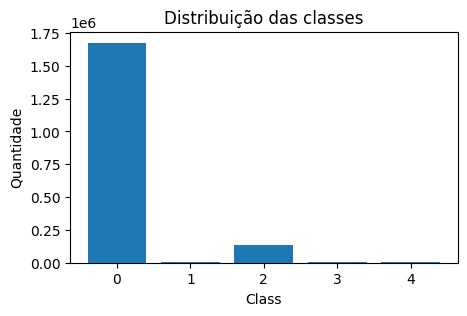

In [13]:
def plot_class_distribution(df, class_col="Class"):
    counts = df[class_col].value_counts().sort_index()
    plt.figure(figsize=(5,3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribuição das classes")
    plt.xlabel("Class")
    plt.ylabel("Quantidade")
    plt.show()
plot_class_distribution(df_train)

In [14]:
df_train['Class'].value_counts()

Class
0    1676045
2     138277
1       8229
4       4308
3       4182
Name: count, dtype: int64

In [15]:
from imblearn.under_sampling import RandomUnderSampler

def aplicar_undersampling_por_proporcao(
    df,
    target_col="Class",
    proporcao=10,
    classe_referencia=None,
    random_state=42
):
    """
    Aplica undersampling no DataFrame inteiro e retorna apenas o DataFrame balanceado.

    proporcao=10 -> classes majoritárias terão no máximo 10x a quantidade da menor classe
    proporcao=20 -> classes majoritárias terão no máximo 20x a quantidade da menor classe
    """

    class_counts = df[target_col].value_counts()

    if classe_referencia is None:
        menor_qtd = class_counts.min()
    else:
        menor_qtd = class_counts[classe_referencia]

    limite = menor_qtd * proporcao

    sampling_strategy = {
        classe: min(qtd, limite)
        for classe, qtd in class_counts.items()
    }

    rus = RandomUnderSampler(
        sampling_strategy=sampling_strategy,
        random_state=random_state
    )

    df_bal, _ = rus.fit_resample(
        df,
        df[target_col]
    )

    return df_bal

In [16]:
df_train_bal = aplicar_undersampling_por_proporcao(
    df_train,
    target_col="Class",
    proporcao=10
)

df_train_bal["Class"].value_counts()


Class
0    41820
2    41820
1     8229
4     4308
3     4182
Name: count, dtype: int64

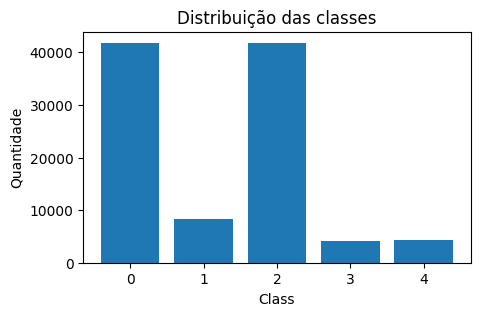

In [17]:
plot_class_distribution(df_train_bal)

# Treinamento

In [21]:
X_train = df_train.drop(columns=["Class"])
X_train_bal = df_train_bal.drop(columns=["Class"])

y_train = df_train["Class"]
y_train_bal = df_train_bal["Class"]

X_test = df_test.drop(columns=["Class"])
y_test = df_test["Class"]

## Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1, class_weight='balanced')
start = time.time()
randomForest.fit(X_train, y_train)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 170.05 segundos


In [27]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest_bal = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
start = time.time()
randomForest_bal.fit(X_train_bal, y_train_bal)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 3.79 segundos


### Salvar RandomForest


In [28]:
import joblib
import os 

#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(randomForest, "./modelo/random_forest.joblib")
joblib.dump(randomForest_bal, "./modelo/random_forest_balanced.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

## XGBoost

In [57]:
from xgboost import XGBClassifier
import time

#xgboost = XGBClassifier(
#    random_state=42,
#    n_estimators=500,
#    learning_rate=0.05,
#    max_depth=6,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    objective='multi:softprob',
#    eval_metric='mlogloss',
#    tree_method='hist',
#    n_jobs=-1
#)

xgboost = XGBClassifier(
    random_state=42,
    n_estimators=100,
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1
)

start = time.time()
xgboost.fit(X_train, y_train)
end = time.time()

print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 48.58 segundos


In [58]:
xgboost_bal = XGBClassifier(
    random_state=42,
    n_estimators=100,
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1
)

start = time.time()
xgboost_bal.fit(X_train_bal, y_train_bal)
end = time.time()

print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 2.84 segundos


### Salvar XGboost

In [25]:
#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(xgboost, "./modelo/xgboost.joblib")
joblib.dump(xgboost_bal, "./modelo/xgboost_balanced.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

## Avaliação do Modelo

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

def show_classification_metrics(y_true, y_pred):
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão gráfica
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

def plot_roc_auc(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR (False Positive Rate)')
    plt.ylabel('TPR (True Positive Rate)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()
    print(f'AUC: {auc:.4f}')

Acurácia: 0.9993315288982678
Precisão: 0.9993521605968179
Recall: 0.9993315288982678
F1 Score: 0.9993371150499635

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.99      1.00      0.99      2057
           2       1.00      1.00      1.00     34569
           3       0.92      1.00      0.95      1046
           4       0.97      1.00      0.98      1077

    accuracy                           1.00    457761
   macro avg       0.97      1.00      0.99    457761
weighted avg       1.00      1.00      1.00    457761



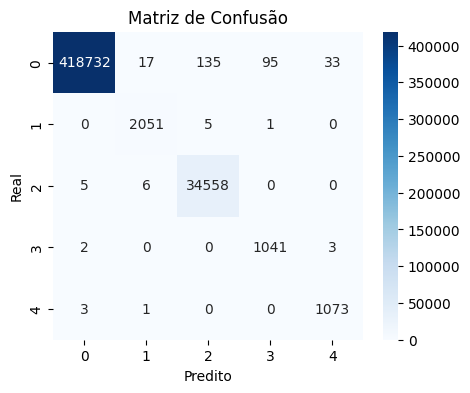

In [62]:
y_predict = xgboost_bal.predict(X_test)
show_classification_metrics(y_test, y_predict)

In [ ]:
from sklearn.metrics import classification_report

relatorio = classification_report(
    y_test,
    y_predict,
    output_dict=True,
    zero_division=0
)

print("Precisão Macro:", relatorio["macro avg"]["precision"])
print("Recall Macro:", relatorio["macro avg"]["recall"])
print("F1 Macro:", relatorio["macro avg"]["f1-score"])

In [35]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


def comparar_modelos_multiclasse(
    modelo_1,
    modelo_2,
    X_test,
    y_test,
    nome_1="Modelo 1",
    nome_2="Modelo 2"
):
    """
    Compara dois modelos de classificação multiclasse no conjunto de teste.

    Retorna:
    - tabela_agregada: métricas gerais dos modelos
    - tabela_por_classe: métricas por classe para cada modelo
    """

    modelos = {
        nome_1: modelo_1,
        nome_2: modelo_2
    }

    resultados_agregados = []
    resultados_por_classe = []

    for nome, modelo in modelos.items():
        y_pred = modelo.predict(X_test)

        # Métricas agregadas
        resultados_agregados.append({
            "Modelo": nome,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision Macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall Macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Precision Weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall Weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1 Weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        })

        # Métricas por classe
        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        for classe, metricas in report.items():
            if classe in ["accuracy", "macro avg", "weighted avg"]:
                continue

            resultados_por_classe.append({
                "Modelo": nome,
                "Classe": classe,
                "Precision": metricas["precision"],
                "Recall": metricas["recall"],
                "F1-score": metricas["f1-score"],
                "Support": metricas["support"]
            })

    tabela_agregada = pd.DataFrame(resultados_agregados).set_index("Modelo")

    tabela_por_classe = pd.DataFrame(resultados_por_classe)
    tabela_por_classe = tabela_por_classe.set_index(["Modelo", "Classe"])

    return tabela_agregada, tabela_por_classe

In [40]:
tabela_agregada, tabela_por_classe = comparar_modelos_multiclasse(
    randomForest,
    xgboost,
    X_test,
    y_test,
    nome_1="random Forest",
    nome_2="XGBoost"
)

display(tabela_agregada)
display(tabela_por_classe)

,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
Modelo,,,,,,,
random Forest,0.999386,0.987537,0.995686,0.991492,0.999392,0.999386,0.999388
XGBoost,0.998617,0.963247,0.978856,0.970768,0.998639,0.998617,0.998625


Precision    Recall  F1-score   Support
Modelo        Classe                                         
random Forest 0        0.999668  0.999687  0.999678  419012.0
              1        0.996590  0.994652  0.995620    2057.0
              2        0.997885  0.996355  0.997119   34569.0
              3        0.945405  0.993308  0.968765    1046.0
              4        0.998136  0.994429  0.996279    1077.0
XGBoost       0        0.999227  0.999303  0.999265  419012.0
              1        0.976778  0.981526  0.979146    2057.0
              2        0.997532  0.993694  0.995609   34569.0
              3        0.882405  0.954111  0.916858    1046.0
              4        0.960295  0.965645  0.962963    1077.0